In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load clean price data
df = pd.read_csv( "C:/Projects/05_bitcoin_forecasting/data/btc_cleaned.csv", header=[0,1], index_col=0, parse_dates=True)
df.columns = ["Close"]

# Resample to weekly (use last price of each week)
weekly = df["Close"].resample("W").last()

weekly.head()

Date
2021-02-21    57539.945312
2021-02-28    45137.769531
2021-03-07    51206.691406
2021-03-14    59302.316406
2021-03-21    57523.421875
Freq: W-SUN, Name: Close, dtype: float64

## 1) Compute Weekly Log Returns

In [3]:
weekly_returns = np.log(weekly / weekly.shift(1))
weekly_returns = weekly_returns.dropna()

weekly_returns.head()

Date
2021-02-28   -0.242760
2021-03-07    0.126151
2021-03-14    0.146778
2021-03-21   -0.030456
2021-03-28   -0.027720
Freq: W-SUN, Name: Close, dtype: float64

## 2) Plot Weekly Returns

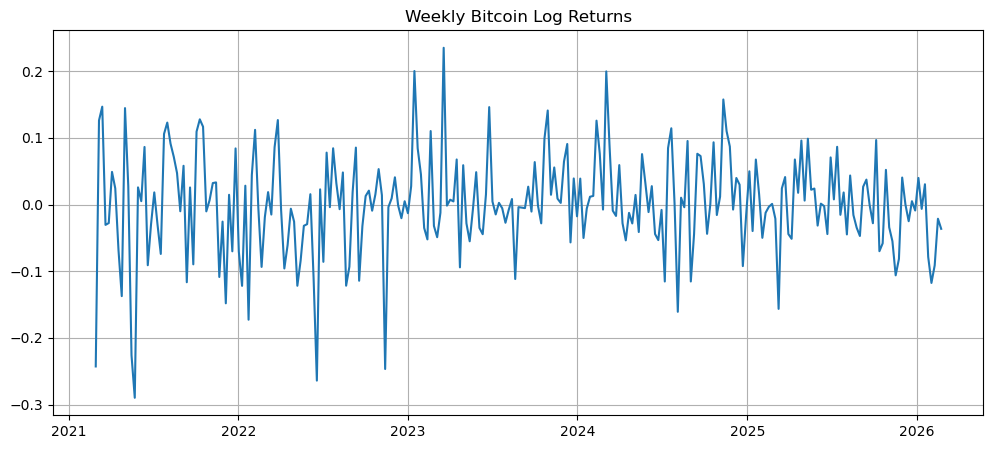

In [4]:
plt.figure(figsize=(12,5))
plt.plot(weekly_returns)
plt.title("Weekly Bitcoin Log Returns")
plt.grid(True)
plt.show()

## 3) ADF Test

In [5]:
from statsmodels.tsa.stattools import adfuller

adf_weekly = adfuller(weekly_returns)

print("ADF Statistic:", adf_weekly[0])
print("p-value:", adf_weekly[1])

ADF Statistic: -14.654490882557127
p-value: 3.458599207599865e-27


## 4) PLot of ACF and PCF for weekly returns

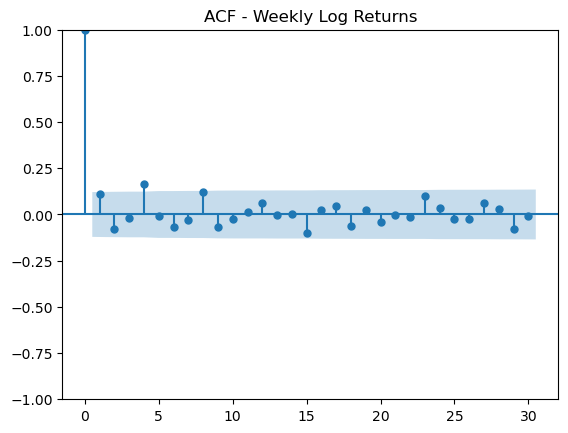

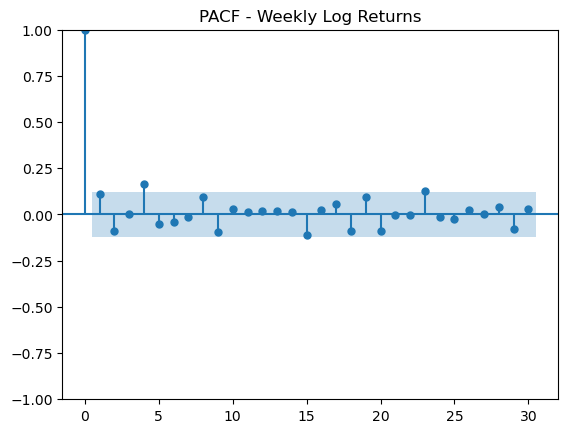

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(weekly_returns, lags=30)
plt.title("ACF - Weekly Log Returns")
plt.show()

plot_pacf(weekly_returns, lags=30)
plt.title("PACF - Weekly Log Returns")
plt.show()

## 5) Train/Test Split


In [7]:
# Convert to numpy
weekly_data = weekly_returns.values

train_size = int(len(weekly_data) * 0.8)

train_weekly = weekly_data[:train_size]
test_weekly = weekly_data[train_size:]

print("Train size:", len(train_weekly))
print("Test size:", len(test_weekly))

Train size: 208
Test size: 53


## 6) Fit ARIMA 



In [8]:
from statsmodels.tsa.arima.model import ARIMA

model_weekly = ARIMA(train_weekly, order=(1,0,1))
fit_weekly = model_weekly.fit()
print(fit_weekly.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  208
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 232.097
Date:                Thu, 05 Mar 2026   AIC                           -456.194
Time:                        06:40:42   BIC                           -442.844
Sample:                             0   HQIC                          -450.796
                                - 208                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.006      0.365      0.715      -0.010       0.015
ar.L1         -0.2012      0.471     -0.427      0.670      -1.125       0.723
ma.L1          0.3380      0.461      0.734      0.4

## 7) Forecast

In [9]:
forecast_weekly = fit_weekly.forecast(steps=len(test_weekly))

## 8) Compute RMSE and MAE

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_weekly = np.sqrt(mean_squared_error(test_weekly, forecast_weekly))
mae_weekly = mean_absolute_error(test_weekly, forecast_weekly)

print("Weekly ARIMA RMSE:", rmse_weekly)
print("Weekly ARIMA MAE:", mae_weekly)

Weekly ARIMA RMSE: 0.05540803718697619
Weekly ARIMA MAE: 0.04336739702121025


## 9) Weekly Baseline

In [11]:
baseline_weekly = np.zeros(len(test_weekly))

rmse_base_weekly = np.sqrt(mean_squared_error(test_weekly, baseline_weekly))
mae_base_weekly = mean_absolute_error(test_weekly, baseline_weekly)

print("Weekly Baseline RMSE:", rmse_base_weekly)
print("Weekly Baseline MAE:", mae_base_weekly)

Weekly Baseline RMSE: 0.055066720895799365
Weekly Baseline MAE: 0.04308195498343015


### Weekly Forecasting Results
To investigare whether time aggregation improves predictability, the daily Bitcoin price series was resampled into weekly frequency and weekly log returns were computed.

An ARIMA model was trained on the weekly return series and compared against a naive baseline model that predicts zero return.

Results:

| Model | RMSE | MAE |
|------|------|------|
| Baseline | 0.05507 | 0.04308 |
| ARIMA | 0.05541 | 0.04337 |

THe ARIMA model does not outperform the baseline, suggesting that the weekly Bitcoin returns also exhibit very weak predictable structure.

These finding reinforce the earlier daily analysis, indicating that past returns alone limited forecasting power for shprt-term Bitcoin return prediction.

# Notebook 6 : Weekly Return Experiment
Goal:
- Resample daily data into weekly frequency
- Compute weekly log returns
- Test stationarity
- Compare predictability with daily results